# **Machine Learning and Forecasting: Seminar 2**

**Preliminary:**
- We refer to an *independent variable* as a *feature*, and *the dependent variable* as *the target*.
- You need the following functions (i.e., to answer Q4), which performs feature selection: forward feature selection and backward feature selection, as indicated by their function names, respectively. Please copy and paste to the place where you need them.
- Interpret the outputs of your answer where applicable.


In [25]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

#########below is a function that implements the forward feature selection method########
def forward_regression(X, y, #the features and the target
                       initial_list=[], # initial list containing no features
                       threshold_in=0.01, #the threshold determining a feature should be included
                       verbose=True): #True: you would like to print "Drop with p-value"
    initial_list = []
    included = list(initial_list)
    while True:
        changed=False
        # forward step
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            # Change argmin -> idxmin
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add with p-value '.format(best_feature, best_pval))

        if not changed:
            break

    return included

# Selected_Features=forward_regression(X, y)# Selected_Features is a list, which provides you the list of selected features

#########end of the forward feature selection method########


#########below is a function that implements the backward feature selection method########
def backward_regression(X, y, # the target and the features
                           threshold_out = 0.05, #the threshold determining a feature should be excluded
                           verbose=True): #True: you would like to print "Drop with p-value"
    included=list(X.columns)
    while True:
        changed=False
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        # use all coefs except intercept
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() # null if pvalues is empty
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop with p-value '.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

# Selected_Features=backward_regression(X, y) # Selected_Features is a list, which provides you the list of selected features
#########end of the backward feature selection method########

# Part A: Questions with hints

Q1: Read the dataset *ENB2012.csv* into Python. The detailed description of this dataset can be found on https://archive.ics.uci.edu/dataset/242/energy+efficiency. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: use drive.mount() to read data into Google Colab from your Google drive:
`from google.colab import drive; drive.mount('/content/drive/')` then use `pd.read_csv` to read your csv file. For an example, you are referred to the seminar questions in Week 1.)
  <font>

In [3]:
ENB2012 = pd.read_csv("Datasets/ENB2012.csv")

Q2. Show the names of all the features and the target in the dataset and the first 5 instances. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: use
`info()` and `head()`)
  <font>


In [4]:
ENB2012.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y2'], dtype='object')

Q3. Write Python code to learn a multiple linear regression model with *Y2* as the target and the rest as the features, including the intercept(i.e., constant) in the model.
<font face="Calibri" size=1.5 color='#3543cd'> (Hint: use
`X_train_data=sm.add_constant(X)` and `sm.OLS(y, X_train_data)` to add an intercept into the regression model and build a model using the OLS (Ordinary Least Square) method, respectively.)
  <font>

In [17]:
# Define x and y
y = ENB2012["Y2"]
X = ENB2012.drop(columns=["Y2"]) 

#Suppose you want to add constant to independent variables X
X_train_data = sm.add_constant(X)

#to fit regression model
model = sm.OLS(y, X_train_data).fit() #where y is the dependent variable and X_train_data is the dependent variables

Q4. Write Python code to perform the forward feature selection method and the backward feature selection method, respectively. Build a regression model on the features selected with each method. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: use the two functions in the "Preliminary" section to answer this question.)
  <font>


In [18]:
fr_variables = forward_regression(X, y) 

Add with p-value 
Add with p-value 
Add with p-value 
Add with p-value 
Add with p-value 
Add with p-value 


In [19]:
br_variables = backward_regression(X, y) 

Drop with p-value 
Drop with p-value 


In [33]:
fr_X = X[fr_variables]

#Suppose you want to add constant to independent variables X
X_train_data = sm.add_constant(fr_X)

#to fit regression model
fr_model = sm.OLS(y, X_train_data).fit() #where y is the dependent variable and X_train_data is the dependent variables

In [34]:
br_X = X[br_variables]

#Suppose you want to add constant to independent variables X
X_train_data = sm.add_constant(br_X)

#to fit regression model
br_model = sm.OLS(y, X_train_data).fit() #where y is the dependent variable and X_train_data is the dependent variables

Q5. Write Python code to draw a residual plot, i.e., a scatter plot with the regression standardised residuals on the Y-axis and the regression fitted values on the X-axis.<font face="Calibri" size=1.5 color='#3543cd'> (Hint: suppose you have trained a model named *model_FFSM* using the forward feature selection method. you can use `model_FFSM.outlier_test` to get studentised residuals, `model_FFSM.fittedvalues` to get the regression fitted values, and use the function `plt.scatter()` to plot a scatter plot.
  <font>

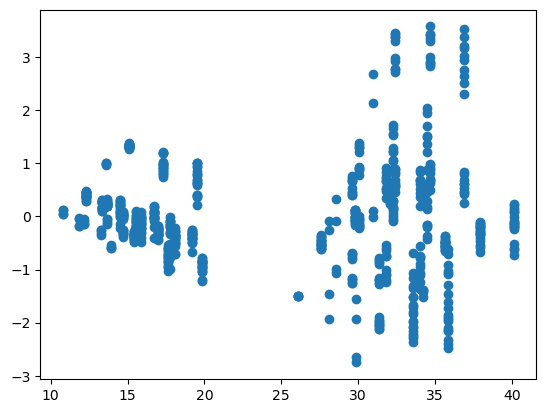

In [36]:
plt.scatter(br_model.fittedvalues, fr_model.outlier_test()['student_resid'])

Q6. Based on the residual plot from Q5, check (a) the nonlinearity of the residuals; and (b) the homogeneity of the residual variance.

Answer: (a) From the residual plot, there is a linear relationship between the target and the features. (b) the residual variance is heterogeneous.

Q7. On the model derived from the forward feature selection method, write Python code to check the autocorelationship among the residuals using the D-W statistic. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: you need a library by performing `from statsmodels.stats.stattools import durbin_watson`, use `model_FFSM.resid` to get the model's residuals and `durbin_watson(residuals)` to obtain the Durbin-Watson statistic.
  <font>

In [41]:
from statsmodels.stats.stattools import durbin_watson

In [42]:
fr_residuals = fr_model.resid
durbin_watson(fr_residuals)

np.float64(1.0954289988379717)

Q8. On the model derived from the forward feature selection method, write Python code to check the independence (i.e., multicolinearity) between the features using VIF (Variance Inflation Factor). <font face="Calibri" size=1.5 color='#3543cd'> (Hint: you need library `from statsmodels.stats.outliers_influence import variance_inflation_factor`. Suppose that the features selected using the forward feature selection method is *X_FFSM*, and add a constant by using `X_BFSM = sm.add_constant(X_BFSM)`, and then you need to use `[variance_inflation_factor(X_FFSM.values, i)
                          for i in range(len(X_FFSM.columns))]` to get the VIF value for each feature.
  <font>

In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [44]:
fr_X = sm.add_constant(fr_X)
[variance_inflation_factor(fr_X.values, i) for i in range(len(fr_X.columns))]

/opt/conda/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


[np.float64(32301.917623443187),
 np.float64(31.20547428099314),
 np.float64(1.0000000000000002),
 np.float64(105.5240541445286),
 np.float64(inf),
 np.float64(inf),
 np.float64(inf)]

Q9. On the model derived from the forward feature selection method, write Python code to check the homogeneity of variance using White's Test. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: Denote `model_FFSM` as the model build using the forward feature selection method. You need a libaray `from statsmodels.stats.diagnostic import het_white`, and can then use `het_white(model_FFSM.resid, model_FFSM.model.exog)` to get White's test.
  <font>

In [45]:
from statsmodels.stats.diagnostic import het_white

In [46]:
het_white(fr_model.resid, fr_model.model.exog)

(np.float64(362.2403848732678),
 np.float64(1.4006098951683644e-66),
 np.float64(39.38586506520559),
 np.float64(7.03227792821164e-92))

Q10. On the model derived from the forward feature selection method, write Python code to perform the Jarque-Bera (J-B) test and create a QQ plot to check whether the residuals follow a normal distribution. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: You can read the last week's seminar solutions for reference.
  <font>

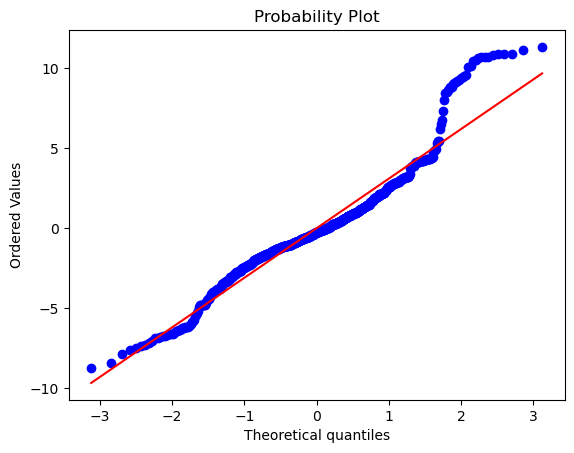

In [48]:
import scipy.stats as stats
#suppose you want to create a QQ plot to check with the variable y is normally distributed
stats.probplot(fr_residuals, dist="norm", plot=plt)
plt.show()

In [50]:
from statsmodels.stats.stattools import jarque_bera
#Suppose you want to perform a statistical test, e.g., the Jarque Bera test and check whether  y  follows the normal distribution (JB_statistic, p_value, skewness, kurtosis)
jbTest = jarque_bera(fr_residuals)

In [51]:
jbTest

(np.float64(232.225259360957),
 np.float64(3.740465474923543e-51),
 np.float64(0.7663893937870956),
 np.float64(5.215316804295155))

Not normally distributed.

Q11. Write Python code to check whether  there are any influential points and outliers? List them if any.<font face="Calibri" size=1.5 color='#3543cd'> (Hint: You need to use a library `import numpy as np`, use `influence = model_FFSM.get_influence()` to create instance of influence, obtain Cook's distance for each observation using `cooks = influence.cooks_distance`. In terms of detecting `outliers`, you can use the studentised residuals from Q5.
  <font>

In [71]:
import numpy as np
influence = fr_model.get_influence()
cooks_d = influence.cooks_distance[0]

# Identify influential observations
influencers = ENB2012.loc[cooks_d > (4 / len(ENB2012))]

influencers

,X1,X2,X3,X4,X5,X6,X7,X8,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.00,0,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.00,0,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.00,0,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.00,0,21.33
9,0.86,588.0,294.0,147.00,7.0,3,0.00,0,21.97
13,0.82,612.5,318.5,147.00,7.0,3,0.00,0,21.46
14,0.82,612.5,318.5,147.00,7.0,4,0.00,0,21.16
16,0.79,637.0,343.0,147.00,7.0,2,0.00,0,37.73
19,0.79,637.0,343.0,147.00,7.0,5,0.00,0,39.44
23,0.76,661.5,416.5,122.50,7.0,5,0.00,0,29.40


In [72]:
student_resid = fr_model.outlier_test()['student_resid']

outliers = ENB2012.loc[abs(student_resid) > 3]
outliers

,X1,X2,X3,X4,X5,X6,X7,X8,Y2
67,0.79,637.0,343.0,147.0,7.0,5,0.10,1,43.33
115,0.79,637.0,343.0,147.0,7.0,5,0.10,2,42.86
160,0.79,637.0,343.0,147.0,7.0,2,0.10,3,43.12
209,0.79,637.0,343.0,147.0,7.0,3,0.10,4,43.30
258,0.79,637.0,343.0,147.0,7.0,4,0.10,5,43.14
307,0.79,637.0,343.0,147.0,7.0,5,0.25,1,45.52
355,0.79,637.0,343.0,147.0,7.0,5,0.25,2,45.97
400,0.79,637.0,343.0,147.0,7.0,2,0.25,3,45.13
449,0.79,637.0,343.0,147.0,7.0,3,0.25,4,45.48
498,0.79,637.0,343.0,147.0,7.0,4,0.25,5,45.28


Q12: Based Q10, does the target follow a normal distribution? If not, perform a Box-Cox tranformation on the dependent variable. You can then re-perform a normality test. If the target follow a normal distribution, then repeat the above questions 4---11; otherwise, other modelling methoods can be used. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: You need to use a library `from scipy import stats`, use `states.boxcox()` to perform a Box-Cox transfermation on the target, then rebuild a model.
  <font>

In [73]:
# Box-Cox transformation
y_bc, lambda_bc = stats.boxcox(y)

lambda_bc

np.float64(-0.10897331821244467)

In [74]:
# Test again for normality by rebuilding
fr_X = X[fr_variables]

#Suppose you want to add constant to independent variables X
X_train_data = sm.add_constant(fr_X)

#to fit regression model
fr_model = sm.OLS(y_bc, X_train_data).fit() #where y is the dependent variable and X_train_data is the dependent variables

In [76]:
fr_residuals = fr_model.resid
jarque_bera(fr_residuals)

(np.float64(32.86048638321151),
 np.float64(7.318735391663113e-08),
 np.float64(0.494057820514872),
 np.float64(3.224761383310696))

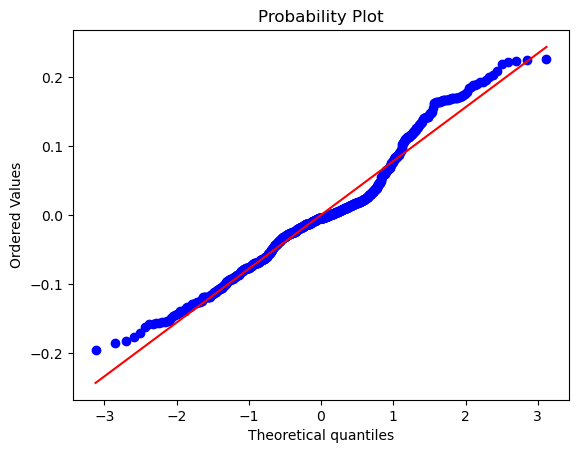

In [77]:
stats.probplot(fr_residuals, dist="norm", plot=plt)
plt.show()

# Part B: Case study

This case study analyses factors affecting real estate valuation using a dataset, Real_estate_valuation_dataset.csv, downloaded from https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set. You need to build a multiple linear regression model using the dataset, and then perform model diagnostics to validate your model's assumptions.

Read the dataset Real_estate_valuation_dataset.csv into Python. Answer the following questions. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: All the following questions are exactly the same as those in Part A. You can therefore simply replace the name of the dataset and use the same Python code written for Part A.
  <font>
- Q1: Read the dataset *Real_estate_valuation_dataset.csv* into Python.
- Q2. Show the names of all the features and the target, which is *Y_house_price_of_unit_area*, in the dataset and the first 5 instances.
- Q3. Write Python code to learn a multiple linear regression model with *Y_house_price_of_unit_area* as the target and the rest features as the independent features, including the intercept (i.e., constant) in the model.
- Q4. Write Python code to perform the forward feature selection method and the backward feature selection method, respectively. Build a regression model on the features selected with each method and interpret the coefficient of your models, respectively.
- Q5. Write Python code to draw a residual plot, i.e., a scatter plot with the regression studentised residuals on the Y-axis and the regression fitted values on the X-axis.
- Q6. Based on the residual plot from Q5, check (a) the nonlinearity of the residuals; and (b) the homogeneity of the residual variance.
- Q7. On the model derived from the forward feature selection method, write Python code to check the autocorelationship among the residuals using the D-W statistic.
- Q8. On the model derived from the forward feature selection method, write Python code to check the independence (i.e., multicolinearity) between the independent features using VIF (Variance Inflation Factor).
- Q9. On the model derived from the forward feature selection method, write Python code to check the homogeneity of variance using White's Test.
- Q10. On the model derived from the forward feature selection method, write Python code to perform the Jarque-Bera (J-B) test and create a QQ plot to check whether the residuals follow a normal distribution.
- Q11. Write Python code to check whether  there are any influential points and outliers? List them if any.
- Q12: Based Q10, does the target follow a normal distribution? If not, perform a Box-Cox tranformation on the target. You can then re-perform a normality test. If the target follow a normal distribution, then repeat the above questions 4---11; otherwise, other modelling methoods can be used.

In [78]:
Real_estate_valuation_dataset = pd.read_csv("Datasets/Real_estate_valuation_dataset.csv")

Q2. Show the names of all the features and the target in the dataset and the first 5 instances. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: use
`info()` and `head()`)
  <font>


In [80]:
Real_estate_valuation_dataset.head(5)

,X1_transaction_date,X2_house_age,X3_distance_to_the_nearest_MRT_station,X4_number_of_convenience_stores,X5_latitude,X6_longitude,Y_house_price_of_unit_area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


Q3. Write Python code to learn a multiple linear regression model with *Y2* as the target and the rest as the features, including the intercept(i.e., constant) in the model.
<font face="Calibri" size=1.5 color='#3543cd'> (Hint: use
`X_train_data=sm.add_constant(X)` and `sm.OLS(y, X_train_data)` to add an intercept into the regression model and build a model using the OLS (Ordinary Least Square) method, respectively.)
  <font>

In [81]:
# Define x and y
y = Real_estate_valuation_dataset["Y_house_price_of_unit_area"]
X = Real_estate_valuation_dataset.drop(columns=["Y_house_price_of_unit_area"]) 

#Suppose you want to add constant to independent variables X
X_train_data = sm.add_constant(X)

#to fit regression model
model = sm.OLS(y, X_train_data).fit() #where y is the dependent variable and X_train_data is the dependent variables

Q4. Write Python code to perform the forward feature selection method and the backward feature selection method, respectively. Build a regression model on the features selected with each method. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: use the two functions in the "Preliminary" section to answer this question.)
  <font>


In [82]:
fr_variables = forward_regression(X, y) 

Add with p-value 
Add with p-value 
Add with p-value 
Add with p-value 
Add with p-value 


In [83]:
br_variables = backward_regression(X, y) 

Drop with p-value 


In [84]:
fr_X = X[fr_variables]

#Suppose you want to add constant to independent variables X
X_train_data = sm.add_constant(fr_X)

#to fit regression model
fr_model = sm.OLS(y, X_train_data).fit() #where y is the dependent variable and X_train_data is the dependent variables

In [85]:
br_X = X[br_variables]

#Suppose you want to add constant to independent variables X
X_train_data = sm.add_constant(br_X)

#to fit regression model
br_model = sm.OLS(y, X_train_data).fit() #where y is the dependent variable and X_train_data is the dependent variables

Q5. Write Python code to draw a residual plot, i.e., a scatter plot with the regression standardised residuals on the Y-axis and the regression fitted values on the X-axis.<font face="Calibri" size=1.5 color='#3543cd'> (Hint: suppose you have trained a model named *model_FFSM* using the forward feature selection method. you can use `model_FFSM.outlier_test` to get studentised residuals, `model_FFSM.fittedvalues` to get the regression fitted values, and use the function `plt.scatter()` to plot a scatter plot.
  <font>

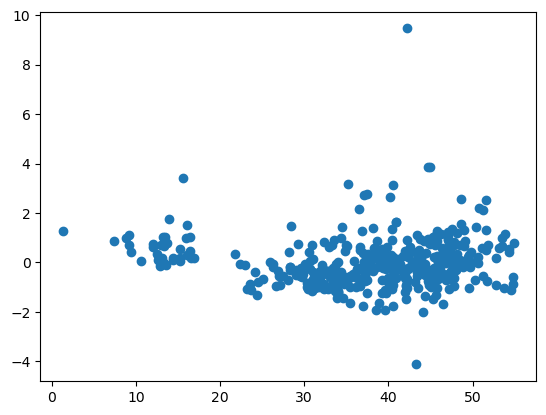

In [86]:
plt.scatter(br_model.fittedvalues, fr_model.outlier_test()['student_resid'])

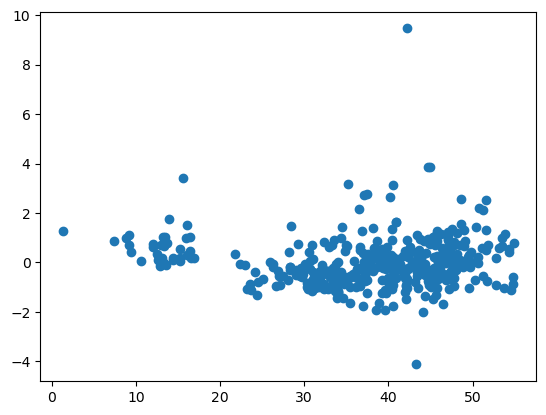

In [87]:
plt.scatter(fr_model.fittedvalues, fr_model.outlier_test()['student_resid'])

Q6. Based on the residual plot from Q5, check (a) the nonlinearity of the residuals; and (b) the homogeneity of the residual variance.

Answer: (a) From the residual plot, there is a linear relationship between the target and the features. (b) the residual variance is heterogeneous.

Q7. On the model derived from the forward feature selection method, write Python code to check the autocorelationship among the residuals using the D-W statistic. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: you need a library by performing `from statsmodels.stats.stattools import durbin_watson`, use `model_FFSM.resid` to get the model's residuals and `durbin_watson(residuals)` to obtain the Durbin-Watson statistic.
  <font>

In [88]:
from statsmodels.stats.stattools import durbin_watson

In [89]:
fr_residuals = fr_model.resid
durbin_watson(fr_residuals)

np.float64(2.154157503908477)

Q8. On the model derived from the forward feature selection method, write Python code to check the independence (i.e., multicolinearity) between the features using VIF (Variance Inflation Factor). <font face="Calibri" size=1.5 color='#3543cd'> (Hint: you need library `from statsmodels.stats.outliers_influence import variance_inflation_factor`. Suppose that the features selected using the forward feature selection method is *X_FFSM*, and add a constant by using `X_BFSM = sm.add_constant(X_BFSM)`, and then you need to use `[variance_inflation_factor(X_FFSM.values, i)
                          for i in range(len(X_FFSM.columns))]` to get the VIF value for each feature.
  <font>

In [90]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [91]:
fr_X = sm.add_constant(fr_X)
[variance_inflation_factor(fr_X.values, i) for i in range(len(fr_X.columns))]

[np.float64(55295503.54144912),
 np.float64(2.0168546616160246),
 np.float64(1.611298536934667),
 np.float64(1.0132430344811645),
 np.float64(1.5856350048897585),
 np.float64(1.0138342574401271)]

Q9. On the model derived from the forward feature selection method, write Python code to check the homogeneity of variance using White's Test. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: Denote `model_FFSM` as the model build using the forward feature selection method. You need a libaray `from statsmodels.stats.diagnostic import het_white`, and can then use `het_white(model_FFSM.resid, model_FFSM.model.exog)` to get White's test.
  <font>

In [92]:
from statsmodels.stats.diagnostic import het_white

In [93]:
het_white(fr_model.resid, fr_model.model.exog)

(np.float64(17.95199792520918),
 np.float64(0.5256468563829311),
 np.float64(0.9399561277897192),
 np.float64(0.5331475114409406))

Q10. On the model derived from the forward feature selection method, write Python code to perform the Jarque-Bera (J-B) test and create a QQ plot to check whether the residuals follow a normal distribution. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: You can read the last week's seminar solutions for reference.
  <font>

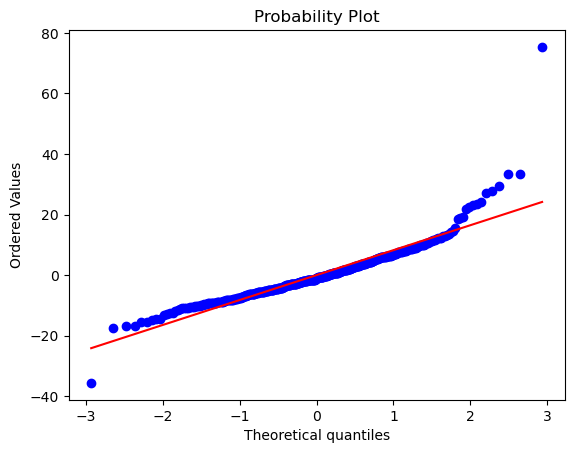

In [94]:
import scipy.stats as stats
#suppose you want to create a QQ plot to check with the variable y is normally distributed
stats.probplot(fr_residuals, dist="norm", plot=plt)
plt.show()

In [95]:
from statsmodels.stats.stattools import jarque_bera
#Suppose you want to perform a statistical test, e.g., the Jarque Bera test and check whether  y  follows the normal distribution (JB_statistic, p_value, skewness, kurtosis)
jbTest = jarque_bera(fr_residuals)

In [96]:
jbTest

(np.float64(3644.712652859077),
 np.float64(0.0),
 np.float64(2.0375884256412444),
 np.float64(16.95279984990781))

Not normally distributed.

Q11. Write Python code to check whether  there are any influential points and outliers? List them if any.<font face="Calibri" size=1.5 color='#3543cd'> (Hint: You need to use a library `import numpy as np`, use `influence = model_FFSM.get_influence()` to create instance of influence, obtain Cook's distance for each observation using `cooks = influence.cooks_distance`. In terms of detecting `outliers`, you can use the studentised residuals from Q5.
  <font>

In [98]:
import numpy as np
influence = fr_model.get_influence()
cooks_d = influence.cooks_distance[0]

# Identify influential observations
influencers = Real_estate_valuation_dataset.loc[cooks_d > (4 / len(ENB2012))]

influencers

,X1_transaction_date,X2_house_age,X3_distance_to_the_nearest_MRT_station,X4_number_of_convenience_stores,X5_latitude,X6_longitude,Y_house_price_of_unit_area
8,2013.500,31.7,5512.03800,1,24.95095,121.48458,18.8
14,2013.500,13.2,1164.83800,4,24.99156,121.53406,34.3
15,2013.583,35.7,579.20830,2,24.98240,121.54619,50.5
16,2013.250,0.0,292.99780,6,24.97744,121.54458,70.1
31,2012.750,29.6,769.40340,7,24.98281,121.53408,25.0
35,2013.500,13.9,4079.41800,0,25.01459,121.51816,27.3
47,2013.583,35.9,640.73910,3,24.97563,121.53715,61.5
88,2012.917,8.9,1406.43000,0,24.98573,121.52758,48.0
105,2012.833,0.0,292.99780,6,24.97744,121.54458,71.0
113,2013.333,14.8,393.26060,6,24.96172,121.53812,7.6


In [99]:
student_resid = fr_model.outlier_test()['student_resid']

outliers = Real_estate_valuation_dataset.loc[abs(student_resid) > 3]
outliers

,X1_transaction_date,X2_house_age,X3_distance_to_the_nearest_MRT_station,X4_number_of_convenience_stores,X5_latitude,X6_longitude,Y_house_price_of_unit_area
113,2013.333,14.8,393.2606,6,24.96172,121.53812,7.6
126,2013.083,38.6,804.6897,4,24.97838,121.53477,62.9
148,2013.500,16.4,3780.5900,0,24.93293,121.51203,45.1
220,2013.333,37.2,186.5101,9,24.97703,121.54265,78.3
270,2013.333,10.8,252.5822,1,24.97460,121.53046,117.5
312,2013.583,35.4,318.5292,9,24.97071,121.54069,78.0
389,2013.250,40.9,122.3619,8,24.96756,121.54230,67.7


Q12: Based Q10, does the target follow a normal distribution? If not, perform a Box-Cox tranformation on the dependent variable. You can then re-perform a normality test. If the target follow a normal distribution, then repeat the above questions 4---11; otherwise, other modelling methoods can be used. <font face="Calibri" size=1.5 color='#3543cd'> (Hint: You need to use a library `from scipy import stats`, use `states.boxcox()` to perform a Box-Cox transfermation on the target, then rebuild a model.
  <font>

In [100]:
# Box-Cox transformation
y_bc, lambda_bc = stats.boxcox(y)

lambda_bc

np.float64(0.5893967555404316)

In [101]:
# Test again for normality by rebuilding
fr_X = X[fr_variables]

#Suppose you want to add constant to independent variables X
X_train_data = sm.add_constant(fr_X)

#to fit regression model
fr_model = sm.OLS(y_bc, X_train_data).fit() #where y is the dependent variable and X_train_data is the dependent variables

In [102]:
fr_residuals = fr_model.resid
jarque_bera(fr_residuals)

(np.float64(1090.356228695768),
 np.float64(1.706684657283537e-237),
 np.float64(0.9886299224164228),
 np.float64(10.700616874121069))

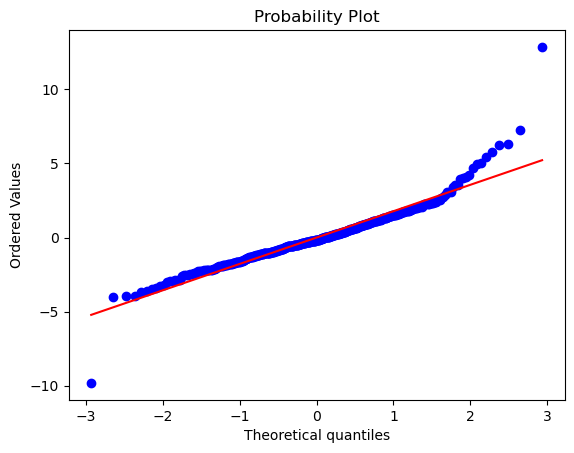

In [103]:
stats.probplot(fr_residuals, dist="norm", plot=plt)
plt.show()


## Wrap-up
- Understand the assumptions of multiple linear regression models, those assumptions include: (1) the normal distribution of the residuls; (2) the autocorelationship among the residuals; (3) the independence (i.e., multi-colinearity) between the independent features; (4) linearity; and (5) the homogeneity of variance;
- Check the validity of each assumption;
- Understand feature selection methods such as the forward feature selection, backward feature selection, and stepwise feature selection methods, respectively.
- Improve the performance of a multiple linear regression model by checking the presence of outliers, influences, or leverages.

## Preparation for the Next Lecture
- To review/google resampling methods such as $k$-fold cross validation methods, the hold-out methods.